In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [3]:
np.random.seed(33550336)

In [4]:
def normeq(X, y):
    return np.linalg.inv(X.T @ X) @ (X.T @ y)

In [12]:
n = 100
tb = np.array([5, 3, -2])
xr = np.random.randn(n , 2)
X = np.column_stack([np.ones(n), xr])
noise = np.random.randn(n)
y = X @ tb + noise

In [13]:
normeq(X, y)

array([ 4.97824678,  2.94192578, -2.11064251])

In [28]:
eta = 0.001 # screw alpha
nter = 1000
binit = np.zeros(3)

In [29]:
sm = np.zeros(1000)

In [30]:
for _ in range(1000):
    tmp = binit - eta * 2/n * X.T @ (X @ binit - y)
    res = X @ tmp - y
    loss = np.mean(res ** 2)
    sm[_] = loss
    binit = tmp

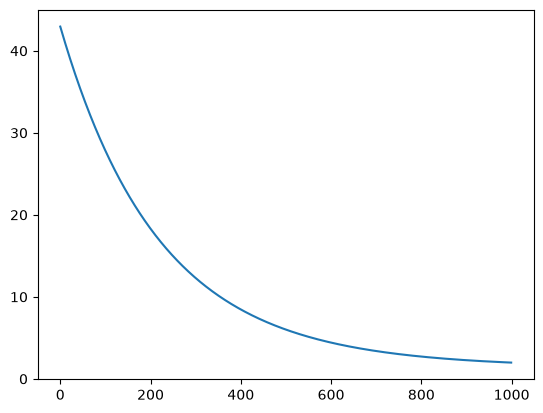

In [33]:
plt.plot(sm)

In [22]:
binit

array([ 4.97824678,  2.94192578, -2.11064251])

In [35]:
from sklearn.datasets import fetch_california_housing

In [36]:
data = fetch_california_housing()
xf = data.data
yf = data.target
n = len(yf)
idx = np.random.permutation(n)
tri = idx[:int(0.8* n)]
tei = idx[:int(0.8 *n)]
xtr = xf[tri]
ytr = yf[tri]
xte = xf[tei]
yte = yf[tei]

In [38]:
np.shape(xtr)

(16512, 8)

In [42]:
xtri = np.column_stack([np.ones(len(xtr)), xtr])
xtei = np.column_stack([np.ones(len(xte)), xte])

In [43]:
normeq(xtri, ytr)

array([-3.67863599e+01,  4.48006995e-01,  9.79810380e-03, -1.26545886e-01,
        8.00383181e-01,  5.64754274e-07, -4.84493797e-03, -4.18795483e-01,
       -4.31402689e-01])

In [45]:
xtei @ normeq(xtri, ytr)

array([2.77370104, 1.00911246, 0.57635373, ..., 2.02015096, 2.24539637,
       2.16291178], shape=(16512,))

In [46]:
np.mean((yte - xtei @ normeq(xtri, ytr)) ** 2)

np.float64(0.5120136004724881)

In [49]:
bh = normeq(xtri, ytr)
yp = xtei @ bh
ssres = np.sum((yte - yp) ** 2)
sstot = np.sum((yte - np.mean(yte)) ** 2)
r2 = 1 - ssres/sstot

In [50]:
r2

np.float64(0.6110178078560105)